### SIADS 696

#### Predicting The Predictor: Regime-Based Error Analysis of BondDroid vs. TRACE
#### Supervised Learning

Processed by: Carter Pasternak


The goal with supervised learning is to determine  mispricing between BondDroid and realized TRACE transaction prices. The target is the absolute difference of TRACE trade price and the most recent BondDroid midpoint ((bid+ask)/2). Models include Ridge/Elastic Net, Random Forest, and Gradient Boosting (XGBoost/LightGBM). Features include things like BondDroid quote data, liquidity and trade metrics, maturity, and coupon structure, Treasury benchmarks, and intraday timing. Pricing errors were also examined within latent market regimes identified through K-Means clustering.


Evaluation uses time-based splits to prevent leakage, current outputs are ranked by MAE, and importance is evaluated for the best model (lowest MAE).

##### Pipeline

1. Data loading and merging
    - Merging datasets, and engineering variables

2. Train-Val-Test 
    - Generating split for TVT in machine learning

3. Models

4. Assessing Best Model

In [140]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 13.3 MB/s  0:00:00


In [22]:
import os
import wrds
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [142]:
# machine learning imports
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
import shap # using version 0.45.1

### 1. Data Loading and Processing

ML_panel is loaded from paths, and displayed to ensure that it is proper. Cluster labels are loaded from the prepared clustering_labeled file, and a prepared cluster lookup is generated. ml_panel and cluster labels are then merged into one dataset using an asof join.

After the dataset is created and merged, features are engineered from timestamps. This includes converting the trade_side (buy, sell) to numerical outputs (1,0), time since last trade into dummy column, and trade_ts into hour, and dayofweek columns, ttm_year is also created from Maturity which is the maturation date represented in years. Alongside this, quantile ranges are calculated for use with a train-val-test split

In [24]:
path = "/Users/carterpasternak/Downloads" # change to wherever file is installed, I have it in my downloads
ml_path= os.path.join(path, "final_ml_panel.parquet")


ml_df = pl.read_parquet(ml_path)
ml_df = ml_df.sort(["FIGI", "trade_ts"])
ml_df.head()

cusip,trace_price,trace_yield,trade_volume,trade_side,trade_ts,FIGI,REGION_East Asia & Pacific,REGION_Europe and Central Asia,REGION_Latin America and Caribbean,REGION_North America,REGION_South Asia,MARKET_SEGMENT_DM Corporate,MARKET_SEGMENT_EM Corporate,bd_ts,bd_mid_px,bd_mid_yield,bd_px_spread,AVG_DAILY_TRADE_COUNT_60,TIMES_TRADED_60,TIME_SINCE_LAST_TRADE,BID_OAS,ASK_OAS,BID_SOT,ASK_SOT,DURATION_MID,CONVEXITY_MID,COUPON,MATURITY,BONDDROID_SECTOR_Accommodation and Food Services,BONDDROID_SECTOR_Administrative and Support and Waste Management and Remediation Services,"BONDDROID_SECTOR_Arts, Entertainment, and Recreation",BONDDROID_SECTOR_Construction,BONDDROID_SECTOR_Finance and Insurance,BONDDROID_SECTOR_Health Care and Social Assistance,BONDDROID_SECTOR_Information,BONDDROID_SECTOR_Management of Companies and Enterprises,BONDDROID_SECTOR_Manufacturing,"BONDDROID_SECTOR_Mining, Quarrying, and Oil and Gas Extraction","BONDDROID_SECTOR_Professional, Scientific, and Technical Services",BONDDROID_SECTOR_Real Estate and Rental and Leasing,BONDDROID_SECTOR_Retail Trade,BONDDROID_SECTOR_Transportation and Warehousing,BONDDROID_SECTOR_Utilities,BONDDROID_SECTOR_Wholesale Trade,BONDDROID_INDUSTRY,TRIGGER_TYPE_ats1_primary,TRIGGER_TYPE_trace_primary,is_snapshot,bd_pricing_failure,quote_age_seconds,target_abs_error,log_volume,OAS_MID,SOT_MID
str,f64,f64,f64,str,datetime[ns],str,u8,u8,u8,u8,u8,u8,u8,datetime[μs],f32,f32,f32,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,datetime[ms],u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,str,u8,u8,bool,bool,f32,f32,f32,f32,f32
"""92343VAF1""",97.545,6.526488,5000.0,"""B""",2023-10-17 10:50:39,"""BBG00000BHR9""",0,0,0,1,0,1,0,2023-10-17 10:00:02,0.284904,0.450976,1.339533,5.167,310.02,"""0-24""",169.503305,164.493355,181.848407,176.802757,8.912703,1.042762,0.0625,2037-04-01 00:00:00,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,"""Wired and Wireless Telecommuni…",1,0,true,false,1.246794,0.197177,-0.897342,0.416558,0.284408
"""92343VAF1""",97.608,6.519267,5000.0,"""S""",2023-10-17 10:50:39,"""BBG00000BHR9""",0,0,0,1,0,1,0,2023-10-17 10:00:02,0.284904,0.450976,1.339533,5.167,310.02,"""0-24""",169.503305,164.493355,181.848407,176.802757,8.912703,1.042762,0.0625,2037-04-01 00:00:00,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,"""Wired and Wireless Telecommuni…",1,0,true,false,1.246794,0.260177,-0.897342,0.416558,0.284408
"""92343VAF1""",97.545,6.526488,5000.0,"""S""",2023-10-17 10:50:39,"""BBG00000BHR9""",0,0,0,1,0,1,0,2023-10-17 10:00:02,0.284904,0.450976,1.339533,5.167,310.02,"""0-24""",169.503305,164.493355,181.848407,176.802757,8.912703,1.042762,0.0625,2037-04-01 00:00:00,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,"""Wired and Wireless Telecommuni…",1,0,true,false,1.246794,0.197177,-0.897342,0.416558,0.284408
"""92343VAF1""",97.608,6.519267,5000.0,"""B""",2023-10-17 10:50:39,"""BBG00000BHR9""",0,0,0,1,0,1,0,2023-10-17 10:00:02,0.284904,0.450976,1.339533,5.167,310.02,"""0-24""",169.503305,164.493355,181.848407,176.802757,8.912703,1.042762,0.0625,2037-04-01 00:00:00,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,"""Wired and Wireless Telecommuni…",1,0,true,false,1.246794,0.260177,-0.897342,0.416558,0.284408
"""92343VAF1""",97.582,6.522246,10000.0,"""B""",2023-10-17 11:32:15,"""BBG00000BHR9""",0,0,0,1,0,1,0,2023-10-17 11:00:02,0.277134,0.454239,1.339533,5.167,310.02,"""0-24""",169.503305,164.493355,181.766443,176.716113,8.912703,1.042762,0.0625,2037-04-01 00:00:00,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,"""Wired and Wireless Telecommuni…",1,0,true,false,0.155775,0.303043,-0.548809,0.416558,0.284059


In [25]:
cluster_path = os.path.join(path, "clustering_labeled.parquet")
cluster_df = pl.read_parquet(cluster_path)


cluster_lookup = (
    cluster_df
    .select(["FIGI", "bd_ts", "cluster"])
    .unique()
    .sort(["FIGI", "bd_ts"])
)

cluster_lookup = cluster_lookup.sort(["FIGI", "bd_ts"])
cluster_lookup.head()

FIGI,bd_ts,cluster
str,datetime[μs],i32
"""BBG00000BHR9""",2023-10-17 10:00:02,2
"""BBG00000BHR9""",2023-10-17 11:00:02,2
"""BBG00000BHR9""",2023-10-17 14:00:01,2
"""BBG00000BHR9""",2023-10-18 10:00:31,2
"""BBG00000BHR9""",2023-10-18 11:00:01,2


In [49]:
# convert timestamps to datetime for asof join
ml_df = ml_df.with_columns(
    pl.col("trade_ts").cast(pl.Datetime("us"))
)

ml_df = ml_df.with_columns(
    pl.col("MATURITY").cast(pl.Datetime("us"))
)

cluster_lookup = cluster_lookup.with_columns(
    pl.col("bd_ts").cast(pl.Datetime("us"))
)

# perform asof join to merge ml_df and cluster_lookup on FIGI and nearest bd_ts <= trade_ts
merged_df = ml_df.join_asof(
    cluster_lookup,
    left_on="trade_ts",
    right_on="bd_ts",
    by="FIGI",
    strategy="backward"
)
merged_df.head()

/var/folders/24/yv4cjz2j4qndh0jby_dyvm_00000gn/T/ipykernel_70786/1708372236.py:15: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  merged_df = ml_df.join_asof(


cusip,trace_price,trace_yield,trade_volume,trade_side,trade_ts,FIGI,REGION_East Asia & Pacific,REGION_Europe and Central Asia,REGION_Latin America and Caribbean,REGION_North America,REGION_South Asia,MARKET_SEGMENT_DM Corporate,MARKET_SEGMENT_EM Corporate,bd_ts,bd_mid_px,bd_mid_yield,bd_px_spread,AVG_DAILY_TRADE_COUNT_60,TIMES_TRADED_60,TIME_SINCE_LAST_TRADE,BID_OAS,ASK_OAS,BID_SOT,ASK_SOT,DURATION_MID,CONVEXITY_MID,COUPON,MATURITY,BONDDROID_SECTOR_Accommodation and Food Services,BONDDROID_SECTOR_Administrative and Support and Waste Management and Remediation Services,"BONDDROID_SECTOR_Arts, Entertainment, and Recreation",BONDDROID_SECTOR_Construction,BONDDROID_SECTOR_Finance and Insurance,BONDDROID_SECTOR_Health Care and Social Assistance,BONDDROID_SECTOR_Information,BONDDROID_SECTOR_Management of Companies and Enterprises,BONDDROID_SECTOR_Manufacturing,"BONDDROID_SECTOR_Mining, Quarrying, and Oil and Gas Extraction","BONDDROID_SECTOR_Professional, Scientific, and Technical Services",BONDDROID_SECTOR_Real Estate and Rental and Leasing,BONDDROID_SECTOR_Retail Trade,BONDDROID_SECTOR_Transportation and Warehousing,BONDDROID_SECTOR_Utilities,BONDDROID_SECTOR_Wholesale Trade,BONDDROID_INDUSTRY,TRIGGER_TYPE_ats1_primary,TRIGGER_TYPE_trace_primary,is_snapshot,bd_pricing_failure,quote_age_seconds,target_abs_error,log_volume,OAS_MID,SOT_MID,bd_ts_right,cluster
str,f64,f64,f64,str,datetime[μs],str,u8,u8,u8,u8,u8,u8,u8,datetime[μs],f32,f32,f32,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,datetime[μs],u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,str,u8,u8,bool,bool,f32,f32,f32,f32,f32,datetime[μs],i32
"""92343VAF1""",97.545,6.526488,5000.0,"""B""",2023-10-17 10:50:39,"""BBG00000BHR9""",0,0,0,1,0,1,0,2023-10-17 10:00:02,0.284904,0.450976,1.339533,5.167,310.02,"""0-24""",169.503305,164.493355,181.848407,176.802757,8.912703,1.042762,0.0625,2037-04-01 00:00:00,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,"""Wired and Wireless Telecommuni…",1,0,true,false,1.246794,0.197177,-0.897342,0.416558,0.284408,2023-10-17 10:00:02,2
"""92343VAF1""",97.608,6.519267,5000.0,"""S""",2023-10-17 10:50:39,"""BBG00000BHR9""",0,0,0,1,0,1,0,2023-10-17 10:00:02,0.284904,0.450976,1.339533,5.167,310.02,"""0-24""",169.503305,164.493355,181.848407,176.802757,8.912703,1.042762,0.0625,2037-04-01 00:00:00,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,"""Wired and Wireless Telecommuni…",1,0,true,false,1.246794,0.260177,-0.897342,0.416558,0.284408,2023-10-17 10:00:02,2
"""92343VAF1""",97.545,6.526488,5000.0,"""S""",2023-10-17 10:50:39,"""BBG00000BHR9""",0,0,0,1,0,1,0,2023-10-17 10:00:02,0.284904,0.450976,1.339533,5.167,310.02,"""0-24""",169.503305,164.493355,181.848407,176.802757,8.912703,1.042762,0.0625,2037-04-01 00:00:00,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,"""Wired and Wireless Telecommuni…",1,0,true,false,1.246794,0.197177,-0.897342,0.416558,0.284408,2023-10-17 10:00:02,2
"""92343VAF1""",97.608,6.519267,5000.0,"""B""",2023-10-17 10:50:39,"""BBG00000BHR9""",0,0,0,1,0,1,0,2023-10-17 10:00:02,0.284904,0.450976,1.339533,5.167,310.02,"""0-24""",169.503305,164.493355,181.848407,176.802757,8.912703,1.042762,0.0625,2037-04-01 00:00:00,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,"""Wired and Wireless Telecommuni…",1,0,true,false,1.246794,0.260177,-0.897342,0.416558,0.284408,2023-10-17 10:00:02,2
"""92343VAF1""",97.582,6.522246,10000.0,"""B""",2023-10-17 11:32:15,"""BBG00000BHR9""",0,0,0,1,0,1,0,2023-10-17 11:00:02,0.277134,0.454239,1.339533,5.167,310.02,"""0-24""",169.503305,164.493355,181.766443,176.716113,8.912703,1.042762,0.0625,2037-04-01 00:00:00,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,"""Wired and Wireless Telecommuni…",1,0,true,false,0.155775,0.303043,-0.548809,0.416558,0.284059,2023-10-17 11:00:02,2


In [50]:
print(f'Merged dataset: {merged_df.shape}, ML panel:  {ml_df.shape}, Cluster dataset: {cluster_df.shape}')

merged_df.select(
    pl.col("cluster").is_null().sum()
)

Merged dataset: (8509326, 57), ML panel:  (8509326, 55), Cluster dataset: (8500577, 26)


cluster
u32
183


In [51]:
merged_df = merged_df.drop_nulls(subset=["cluster"])
print(f'Merged dataset after dropping nulls: {merged_df.shape}')
merged_df.select(
    pl.col("cluster").is_null().sum()
)

Merged dataset after dropping nulls: (8509143, 57)


cluster
u32
0


In [52]:

merged_df = merged_df.with_columns([
    pl.col("trade_ts").dt.hour().alias("hour"),
    pl.col("trade_ts").dt.weekday().alias("dayofweek")
])

merged_df = merged_df.with_columns(
    ((pl.col("MATURITY") - pl.col("trade_ts")).dt.total_days() / 365.25).alias("ttm_years")
)

merged_df = merged_df.with_columns(
    pl.col("trade_side").replace({"B": 1, "S": 0}).cast(pl.Int8).alias("trade_side_encoded")
)

merged_df = merged_df.to_dummies(["TIME_SINCE_LAST_TRADE"])

merged_df[["trade_ts", "dayofweek", "hour", "trade_side_encoded","ttm_years"]].head()

trade_ts,dayofweek,hour,trade_side_encoded,ttm_years
datetime[μs],i8,i8,i8,f64
2023-10-17 10:50:39,2,10,1,13.453799
2023-10-17 10:50:39,2,10,0,13.453799
2023-10-17 10:50:39,2,10,0,13.453799
2023-10-17 10:50:39,2,10,1,13.453799
2023-10-17 11:32:15,2,11,1,13.453799


In [53]:
# ensure that the dataframe is sorted by trade timestamp, 
df_final = merged_df.sort("trade_ts") 
df_final.head()

cusip,trace_price,trace_yield,trade_volume,trade_side,trade_ts,FIGI,REGION_East Asia & Pacific,REGION_Europe and Central Asia,REGION_Latin America and Caribbean,REGION_North America,REGION_South Asia,MARKET_SEGMENT_DM Corporate,MARKET_SEGMENT_EM Corporate,bd_ts,bd_mid_px,bd_mid_yield,bd_px_spread,AVG_DAILY_TRADE_COUNT_60,TIMES_TRADED_60,TIME_SINCE_LAST_TRADE_0-24,TIME_SINCE_LAST_TRADE_24-48,TIME_SINCE_LAST_TRADE_48-72,TIME_SINCE_LAST_TRADE_72+,TIME_SINCE_LAST_TRADE_null,BID_OAS,ASK_OAS,BID_SOT,ASK_SOT,DURATION_MID,CONVEXITY_MID,COUPON,MATURITY,BONDDROID_SECTOR_Accommodation and Food Services,BONDDROID_SECTOR_Administrative and Support and Waste Management and Remediation Services,"BONDDROID_SECTOR_Arts, Entertainment, and Recreation",BONDDROID_SECTOR_Construction,BONDDROID_SECTOR_Finance and Insurance,BONDDROID_SECTOR_Health Care and Social Assistance,BONDDROID_SECTOR_Information,BONDDROID_SECTOR_Management of Companies and Enterprises,BONDDROID_SECTOR_Manufacturing,"BONDDROID_SECTOR_Mining, Quarrying, and Oil and Gas Extraction","BONDDROID_SECTOR_Professional, Scientific, and Technical Services",BONDDROID_SECTOR_Real Estate and Rental and Leasing,BONDDROID_SECTOR_Retail Trade,BONDDROID_SECTOR_Transportation and Warehousing,BONDDROID_SECTOR_Utilities,BONDDROID_SECTOR_Wholesale Trade,BONDDROID_INDUSTRY,TRIGGER_TYPE_ats1_primary,TRIGGER_TYPE_trace_primary,is_snapshot,bd_pricing_failure,quote_age_seconds,target_abs_error,log_volume,OAS_MID,SOT_MID,bd_ts_right,cluster,hour,dayofweek,ttm_years,trade_side_encoded
str,f64,f64,f64,str,datetime[μs],str,u8,u8,u8,u8,u8,u8,u8,datetime[μs],f32,f32,f32,f64,f64,u8,u8,u8,u8,u8,f64,f64,f64,f64,f64,f64,f64,datetime[μs],u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,str,u8,u8,bool,bool,f32,f32,f32,f32,f32,datetime[μs],i32,i8,i8,f64,i8
"""654106AH6""",95.942,5.322702,1.587e6,"""S""",2023-10-05 23:31:28,"""BBG00ST5XXV2""",0,0,0,1,0,1,0,2023-10-05 23:00:01,0.107465,-0.00319,-0.724442,10.45,627.0,1,0,0,0,0,42.701266,41.201266,45.580225,43.25968,1.407324,0.026796,0.024,2025-03-27 00:00:00,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,"""Footwear Manufacturing""",0,1,false,false,0.110315,0.166865,1.999337,-0.499202,-0.27403,2023-10-05 23:00:01,0,23,4,1.472964,0
"""478160CT9""",53.806,5.322042,2000.0,"""B""",2023-10-05 23:49:02,"""BBG00WVM0X12""",0,0,0,1,0,1,0,2023-10-05 23:00:01,-4.637289,-0.051014,-0.111909,7.517,451.02,1,0,0,0,0,48.586054,47.086054,45.540956,44.044912,18.868005,5.385938,0.0245,2060-09-01 00:00:00,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,"""Pharmaceutical and Medicine Ma…",0,1,false,false,1.151922,0.084909,-1.357993,-0.456106,-0.272487,2023-10-05 23:00:01,2,23,4,36.906229,1
"""478160CT9""",53.806,5.322042,2000.0,"""S""",2023-10-05 23:49:02,"""BBG00WVM0X12""",0,0,0,1,0,1,0,2023-10-05 23:00:01,-4.637289,-0.051014,-0.111909,7.517,451.02,1,0,0,0,0,48.586054,47.086054,45.540956,44.044912,18.868005,5.385938,0.0245,2060-09-01 00:00:00,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,"""Pharmaceutical and Medicine Ma…",0,1,false,false,1.151922,0.084909,-1.357993,-0.456106,-0.272487,2023-10-05 23:00:01,2,23,4,36.906229,0
"""61746BEF9""",93.078,5.981461,2000.0,"""B""",2023-10-06 08:00:05,"""BBG00FRY84X9""",0,0,0,1,0,1,0,2023-10-06 08:00:01,-0.203591,0.225912,-0.377787,93.917,5635.02,1,0,0,0,0,119.831021,116.289217,131.440395,127.892733,2.998614,0.108055,0.03625,2027-01-20 00:00:00,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,"""Portfolio Management """,0,1,true,false,-1.750544,0.059834,-1.357993,0.058168,0.078846,2023-10-06 08:00:01,3,8,5,3.288159,1
"""61746BEF9""",93.078,5.981461,2000.0,"""S""",2023-10-06 08:00:05,"""BBG00FRY84X9""",0,0,0,1,0,1,0,2023-10-06 08:00:01,-0.203591,0.225912,-0.377787,93.917,5635.02,1,0,0,0,0,119.831021,116.289217,131.440395,127.892733,2.998614,0.108055,0.03625,2027-01-20 00:00:00,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,"""Portfolio Management """,0,1,true,false,-1.750544,0.059834,-1.357993,0.058168,0.078846,2023-10-06 08:00:01,3,8,5,3.288159,0


#### 2. Train-Val-Test (TVT)
After the datasets are merged and features are engineered, a train-val-test split is created based on the timeframe to ensure data leakage is mitigated. This is done using a function to make the X and Y values ensuring reproducability. 

Exact timestamps were excluded from modeling to prevent the model from learning date specific effects. Instead, cyclical information such as hour of day, and day of week features are used. Raw features are removed where engineered features exist, and targets are removed, along with the features that directly calculate them. Data leakage is also removed, which includes trace price, which may only be known at the time of the sale/purchase of a bond.

In [54]:
# Check the breakdown of the time series data, this is used for setting train test split so that time frame is 70-15-15, ensuring that temporal leakage is mitigated and the model is not trained on data that is too close to the test set
df_final["trade_ts"].quantile([0.7, 0.85])

[datetime.datetime(2024, 10, 9, 10, 0, 53),
 datetime.datetime(2025, 1, 6, 11, 33, 27)]

In [55]:
df_final = df_final.to_pandas()
train_end = pd.Timestamp("2024-10-09 09:58:12")
val_end = pd.Timestamp("2025-01-06 11:32:52")

train = df_final[df_final["trade_ts"] <= train_end]

val = df_final[
    (df_final["trade_ts"] > train_end) &
    (df_final["trade_ts"] <= val_end)
]

test = df_final[df_final["trade_ts"] > val_end]

test_eval = test.copy() # this is the test set that will be used for final evaluation

#### 3. Baseline Models

Use the dataset and TVT split with features to test supervised learning and examine pricing failures without regimes.

Ridge -

Lasso -



In [56]:
drop_cols = [
    #target
    "target_abs_error", 
    "bd_pricing_failure",
    
    #leakage 
    "trace_price", 
    "bd_mid_px",
    "trace_yield", 

    #identifiers
    "cusip",
    "FIGI",
    "BONDDROID_INDUSTRY", #engineered feature is used instead
    "cluster",
    
    #timestamps
    "trade_ts", # not needed, as it may cause leakage or over estimation, will use hour/day instead
    "bd_ts", "bd_ts_right", # from the merge, not needed, as it may cause leakage or over estimation, will use hour/day instead
    "MATURITY",
    
    #encoded features
    "trade_side",
    "TIME_SINCE_LAST_TRADE",
    
    
    #
    "BID_SOT", "ASK_SOT",
    "BID_OAS", "ASK_OAS",
    
    #raw volume
    "trade_volume", "AVG_DAILY_TRADE_COUNT_60", "TIMES_TRADED_60"
    ] 

def make_xy(df):
    X = df.drop(columns= drop_cols
    , errors="ignore").copy()

    y =df["target_abs_error"].copy()

    return X, y

In [57]:
# create X and Y for train, val and test sets

X_train, y_train = make_xy(train) 
X_val, y_val = make_xy(val)
X_test, y_test = make_xy(test)

#### Ridge Regression:

In [164]:
alphas = [0.01,0.1, 1.0, 10.0, 100.0, 1000.0]
best_mae = float("inf")

scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)


for a in alphas:
    ridge_model = Ridge(alpha=a)
    ridge_model.fit(X_train_s, y_train)
    val_pred = ridge_model.predict(X_val_s)
    val_mae = mean_absolute_error(y_val, val_pred)
    print(f"Alpha: {a}, Validation MAE: {val_mae}")
    
    if val_mae < best_mae:
        best_mae = val_mae
        best_alpha = a
print(best_mae, best_alpha)


Alpha: 0.01, Validation MAE: 0.3358719831004137
Alpha: 0.1, Validation MAE: 0.33587087092240614
Alpha: 1.0, Validation MAE: 0.3358704715929504
Alpha: 10.0, Validation MAE: 0.33586755033104465
Alpha: 100.0, Validation MAE: 0.33583848923874476
Alpha: 1000.0, Validation MAE: 0.3355521864125918
0.3355521864125918 1000.0


In [168]:
ridge_model = Ridge(alpha=a)
ridge_model.fit(X_train_s, y_train)
test_pred = ridge_model.predict(X_test_s)
ridge_mae = mean_absolute_error(y_test, test_pred)
print(f"Validation MAE: {ridge_mae}")

Validation MAE: 0.39411914809526255


Validation MAE: 0.39411914809526255

In [111]:
coef_df_r = {}

for c in sorted(test_eval["cluster"].unique()):
    
    sub = test_eval[test_eval["cluster"] == c]
    
    X = sub.drop(columns= drop_cols, errors = "ignore").copy()
    y = sub["target_abs_error"].copy()
    
    scaler = StandardScaler()
    X_s = scaler.fit_transform(X)
    
    model = Ridge(alpha=best_alpha)
    model.fit(X_s, y)
    
    coef_df_r[c] = pd.DataFrame({
        "feature": X.columns,
        "coefficient": model.coef_,
        "abs_coefficient": np.abs(model.coef_)
    }).sort_values(by="abs_coefficient", ascending=False)
    print(f"Cluster {c} - Top 5 Features by Absolute Coefficient Value:")
    print(coef_df_r[c].head(5))
    

Cluster 0 - Top 5 Features by Absolute Coefficient Value:
          feature  coefficient  abs_coefficient
42      ttm_years     0.312903         0.312903
14   DURATION_MID    -0.218696         0.218696
39        SOT_MID    -0.067516         0.067516
7    bd_mid_yield     0.066782         0.066782
15  CONVEXITY_MID    -0.059514         0.059514
Cluster 1 - Top 5 Features by Absolute Coefficient Value:
          feature  coefficient  abs_coefficient
39        SOT_MID    -7.208977         7.208977
7    bd_mid_yield     7.071723         7.071723
15  CONVEXITY_MID     2.416704         2.416704
14   DURATION_MID    -1.635716         1.635716
42      ttm_years    -1.494063         1.494063
Cluster 2 - Top 5 Features by Absolute Coefficient Value:
                               feature  coefficient  abs_coefficient
38                             OAS_MID    -0.596480         0.596480
39                             SOT_MID     0.424783         0.424783
15                       CONVEXITY_MID     

#### Lasso Regression:

In [166]:
best_mae = float("inf")
for a in alphas:
    lasso_model = Lasso(alpha=a, max_iter=10000)
    lasso_model.fit(X_train_s, y_train)
    val_pred = lasso_model.predict(X_val_s)
    val_mae = mean_absolute_error(y_val, val_pred)
    print(f"Alpha: {a}, Validation MAE: {val_mae}")
    
    if val_mae < best_mae:
        best_mae = val_mae
        best_alpha = a
print(best_mae, best_alpha)

Alpha: 0.01, Validation MAE: 0.3037241018380943
Alpha: 0.1, Validation MAE: 0.30817229800151785
Alpha: 1.0, Validation MAE: 0.3351202692773466
Alpha: 10.0, Validation MAE: 0.3351202692773466
Alpha: 100.0, Validation MAE: 0.3351202692773466
Alpha: 1000.0, Validation MAE: 0.3351202692773466
0.3037241018380943 0.01


In [170]:
lasso_model = Lasso(alpha=0.01, max_iter=10000)
lasso_model.fit(X_train_s, y_train)
test_pred = lasso_model.predict(X_test_s)
lasso_mae = mean_absolute_error(y_test, test_pred)

print(f"Final MAE: {lasso_mae}")

Final MAE: 0.3173517204038546


Final MAE: 0.3173517204038546

In [127]:
coef_df_l = {}
for c in sorted(test_eval["cluster"].unique()):
    
    sub = test_eval[test_eval["cluster"] == c]
    
    X = sub.drop(columns= drop_cols, errors = "ignore").copy()
    y = sub["target_abs_error"].copy()
    
    scaler = StandardScaler()
    X_s = scaler.fit_transform(X)
    
    model = Lasso(alpha=best_alpha,max_iter=10000)
    model.fit(X_s, y)
    
    coef_df_l[c] = pd.DataFrame({
        "feature": X.columns,
        "coefficient": model.coef_,
        "abs_coefficient": np.abs(model.coef_)
    }).sort_values(by="abs_coefficient", key=abs, ascending=False)
    print(f"Cluster {c} - Top 5 Features by Absolute Coefficient Value:")
    print(coef_df_l[c].head(5))
    

Cluster 0 - Top 5 Features by Absolute Coefficient Value:
                         feature  coefficient  abs_coefficient
42                     ttm_years     0.037607         0.037607
8                   bd_px_spread     0.025120         0.025120
40                          hour    -0.003286         0.003286
43            trade_side_encoded    -0.002839         0.002839
23  BONDDROID_SECTOR_Information    -0.001144         0.001144
Cluster 1 - Top 5 Features by Absolute Coefficient Value:
          feature  coefficient  abs_coefficient
15  CONVEXITY_MID     1.209181         1.209181
14   DURATION_MID    -0.815932         0.815932
42      ttm_years    -0.748905         0.748905
38        OAS_MID     0.622915         0.622915
8    bd_px_spread     0.492327         0.492327
Cluster 2 - Top 5 Features by Absolute Coefficient Value:
                               feature  coefficient  abs_coefficient
2   REGION_Latin America and Caribbean     0.259824         0.259824
16                    

#### LGBM Regression

Testing LGBM Regression evaluating based on MAE. Columns had to be renamed as LGBM did not support characters.

In [61]:
def clean_feature_names(df):
    df = df.copy()
    df.columns = [
        re.sub(r"[^0-9a-zA-Z_]+", "_", col).strip("_")
        for col in df.columns
    ]
    return df

In [ ]:
X_train_lgb = clean_feature_names(X_train)
X_val_lgb   = clean_feature_names(X_val)
X_test_lgb  = clean_feature_names(X_test)

lgbm_model = LGBMRegressor(random_state=42)


lgbm_model.fit(X_train_lgb, y_train, eval_set=[(X_val_lgb, y_val)], eval_metric="mae")

test_pred_lgb = lgbm_model.predict(X_test_lgb)

test_mae_lgb = mean_absolute_error(y_test, test_pred_lgb)
print("FINAL TEST MAE (LightGBM):", test_mae_lgb)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.148125 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2636
[LightGBM] [Info] Number of data points in the train set: 5956349, number of used features: 43
[LightGBM] [Info] Start training from score 0.417257
FINAL TEST MAE (LightGBM): 0.37263427343926814


FINAL TEST MAE (LightGBM): 0.37263427343926814

In [99]:
coef_df_lgb = {}
for c in sorted(test_eval["cluster"].unique()):
    
    sub = test_eval[test_eval["cluster"] == c]
    
    X = sub.drop(columns= drop_cols, errors = "ignore").copy()
    y = sub["target_abs_error"].copy()
    
    X_lgb = clean_feature_names(X)
    
    model =  LGBMRegressor(random_state=42)
    model.fit(X_lgb, y)
    
    coef_df_lgb[c] = pd.DataFrame({
        "feature": X.columns,
        "Importance":  model.booster_.feature_importance(importance_type="gain")
    }).sort_values(by="Importance", key=abs, ascending=False)
    print(f"Cluster {c} - Top 5 Features by Importance:")
    print(coef_df_lgb[c].head(5))
    

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012685 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2558
[LightGBM] [Info] Number of data points in the train set: 779485, number of used features: 40
[LightGBM] [Info] Start training from score 0.202419
Cluster 0 - Top 5 Features by Importance:
         feature    Importance
16        COUPON  90728.197184
14  DURATION_MID  47657.676114
37    log_volume  37406.503138
42     ttm_years  26160.593658
8   bd_px_spread  22307.963702
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001985 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2421
[LightGBM] [Info] Number of data points in the train set: 73746, number of used features: 32
[LightGBM] [

#### XGBoost

In [149]:
best_mae = float("inf") 
best_params = {}

for md in [2,4,6]:
    for n_est in [50,100,200,1000]:
        xgb_model = XGBRegressor(
                objective="reg:squarederror",
                random_state=42,
                n_estimators=n_est,
                max_depth=md,
                learning_rate=0.1,
                eval_metric="mae"
            )

        xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

        val_pred = xgb_model.predict(X_val)
        val_mae = mean_absolute_error(y_val, val_pred)
                
        if val_mae < best_mae:
            best_mae = val_mae
            best_params = {"max_depth": md,
                            "n_estimators": n_est
                            }

                
print("BEST MAE (XGBoost):", best_mae)
print("BEST PARAMS (XGBoost):", best_params)

BEST MAE (XGBoost): 0.29525697231292725
BEST PARAMS (XGBoost): {'max_depth': 2, 'n_estimators': 50}


BEST MAE (XGBoost): 0.29525697231292725
BEST PARAMS (XGBoost): {'max_depth': 2, 'n_estimators': 50}

In [173]:
best_xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_estimators=50,
    max_depth=2,
    learning_rate=0.1,
    eval_metric="mae",
)

best_xgb.fit(X_train, y_train)

test_pred = best_xgb.predict(X_test)

xgb_mae = mean_absolute_error(y_test, test_pred)
importance_xgb_com = pd.DataFrame({
        "feature": X.columns,
        "Importance":  model.feature_importances_
    }).sort_values(by="Importance", key=abs, ascending=False)

print("FINAL TEST MAE:", xgb_mae)

FINAL TEST MAE: 0.2902626395225525


In [151]:
coef_df_xgb = {}
for c in sorted(test_eval["cluster"].unique()):
    
    sub = test_eval[test_eval["cluster"] == c]
    
    X = sub.drop(columns= drop_cols, errors = "ignore").copy()
    y = sub["target_abs_error"].copy()
    
    
    model =  XGBRegressor(
                objective="reg:squarederror",
                random_state=42,
                n_estimators=50,
                max_depth=2,
                learning_rate=0.1,
                eval_metric="mae"
            )
    model.fit(X, y)
    
    coef_df_xgb[c] = pd.DataFrame({
        "feature": X.columns,
        "Importance":  model.feature_importances_
    }).sort_values(by="Importance", key=abs, ascending=False)
    print(f"Cluster {c} - Top 5 Features by Importance:")
    print(coef_df_xgb[c].head(5))
    

Cluster 0 - Top 5 Features by Importance:
                                              feature  Importance
36                                  quote_age_seconds    0.644286
14                                       DURATION_MID    0.160861
42                                          ttm_years    0.044413
27  BONDDROID_SECTOR_Professional, Scientific, and...    0.029411
16                                             COUPON    0.028926
Cluster 1 - Top 5 Features by Importance:
                               feature  Importance
38                             OAS_MID    0.593649
14                        DURATION_MID    0.073194
12           TIME_SINCE_LAST_TRADE_72+    0.068398
2   REGION_Latin America and Caribbean    0.061745
15                       CONVEXITY_MID    0.051608
Cluster 2 - Top 5 Features by Importance:
                           feature  Importance
15                   CONVEXITY_MID    0.257012
8                     bd_px_spread    0.184057
14                    DURATION_

#### Random Forest

In [159]:
for md in [4,6,8]:
    for n_est in [100,200]:
        rf = RandomForestRegressor(
        n_estimators=n_est,
        max_depth=md,
        random_state=42,
        n_jobs=-1)

        rf.fit(X_train, y_train)

        val_pred = rf.predict(X_val)
        val_mae = mean_absolute_error(y_val, val_pred)
                
        if val_mae < best_mae:
            best_mae = val_mae
            best_params = {"max_depth": md,
                            "n_estimators": n_est
                            }
                
print("BEST MAE (RF):", best_mae)
print("BEST PARAMS (RF):", best_params)

BEST MAE (RF): 0.2900011286924089
BEST PARAMS (RF): {'max_depth': 4, 'n_estimators': 100}


In [172]:
rf_best = RandomForestRegressor(
        n_estimators=100,
        max_depth=4,
        random_state=42,
        n_jobs=-1)

rf_best.fit(X_train, y_train)

rf_best_pred = rf.predict(X_test)
rf_best_mae = mean_absolute_error(y_test, val_pred)

importance_rf_com = pd.DataFrame({
        "feature": X.columns,
        "Importance":  rf_best.feature_importances_
    }).sort_values(by="Importance", key=abs, ascending=False)

print("FINAL TEST MAE:", rf_best_mae)
print("Importances:", importance_rf_com )

FINAL TEST MAE: 0.33122899378490095
Importances:                                               feature    Importance
38                                            OAS_MID  3.803263e-01
8                                        bd_px_spread  2.523445e-01
40                                               hour  1.957881e-01
16                                             COUPON  7.357322e-02
14                                       DURATION_MID  3.732960e-02
39                                            SOT_MID  1.584270e-02
25                     BONDDROID_SECTOR_Manufacturing  1.414632e-02
15                                      CONVEXITY_MID  1.397114e-02
42                                          ttm_years  1.207728e-02
7                                        bd_mid_yield  2.305285e-03
36                                  quote_age_seconds  1.997040e-03
12                          TIME_SINCE_LAST_TRADE_72+  2.985219e-04
41                                          dayofweek  5.089345e-10

In [160]:
importances_rf={}
for c in sorted(test_eval["cluster"].unique()):
    
    sub = test_eval[test_eval["cluster"] == c]
    
    X = sub.drop(columns= drop_cols, errors = "ignore").copy()
    y = sub["target_abs_error"].copy()
    
    model =  RandomForestRegressor(
        n_estimators=100,
        max_depth=4,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X, y)
    
    importances_rf[c] = pd.DataFrame({
        "feature": X.columns,
        "Importance":  model.feature_importances_
    }).sort_values(by="Importance", key=abs, ascending=False)
    print(f"Cluster {c} - Top 5 Features by Importance:")
    print(importances_rf[c].head(5))

Cluster 0 - Top 5 Features by Importance:
              feature  Importance
16             COUPON    0.279167
36  quote_age_seconds    0.133639
15      CONVEXITY_MID    0.123597
42          ttm_years    0.100146
35        is_snapshot    0.090700
Cluster 1 - Top 5 Features by Importance:
          feature  Importance
38        OAS_MID    0.619838
14   DURATION_MID    0.160675
42      ttm_years    0.082929
15  CONVEXITY_MID    0.067905
8    bd_px_spread    0.023562
Cluster 2 - Top 5 Features by Importance:
                               feature  Importance
39                             SOT_MID    0.184004
16                              COUPON    0.163512
25      BONDDROID_SECTOR_Manufacturing    0.111812
8                         bd_px_spread    0.110613
2   REGION_Latin America and Caribbean    0.108227
Cluster 3 - Top 5 Features by Importance:
          feature  Importance
42      ttm_years    0.307707
8    bd_px_spread    0.228191
15  CONVEXITY_MID    0.122706
39        SOT_MID    0

#### Assessing the best model

In [174]:
results = []

results.append({
    "model": "Ridge",
    "mae": ridge_mae
})

results.append({
    "model": "Lasso",
    "mae": lasso_mae
})

results.append({
    "model": "LightGBM",
    "mae": test_mae_lgb
})

results.append({
    "model": "XGBoost",
    "mae": xgb_mae
})

results.append({
    "model": "Random Forest",
    "mae": rf_best_mae
})

ranking = (
    pd.DataFrame(results)
    .sort_values("mae")
    .reset_index(drop=True)
)

ranking["rank"] = ranking.index + 1

print(ranking)

           model       mae  rank
0        XGBoost  0.290263     1
1          Lasso  0.317352     2
2  Random Forest  0.331229     3
3       LightGBM  0.372634     4
4          Ridge  0.394119     5


     model        mae      rank
    XGBoost    0.290263     1
    Lasso      0.317352     2
    RF         0.331229     3
    LGBM       0.372634     4
    Ridge      0.394119     5

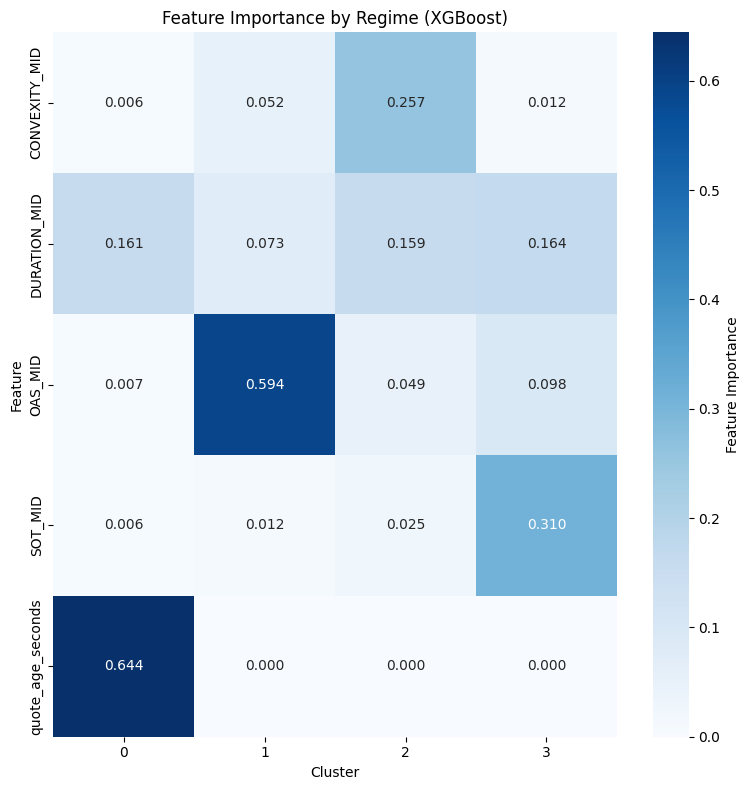

In [179]:
all_features = pd.concat(
    [imp.assign(cluster=c) for c, imp in coef_df_xgb.items()]
)

# Top features by average importance across clusters
top_features = (
    all_features.groupby("feature")["Importance"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
    .index
)

filtered = all_features[
    all_features["feature"].isin(top_features)
]

importance_heatmap = filtered.pivot_table(
    index="feature",
    columns="cluster",
    values="Importance",
    fill_value=0
)

plt.figure(figsize=(8,8))
sns.heatmap(
    importance_heatmap,
    annot=True,
    fmt=".3f",
    square=True,
    cmap="Blues",
    cbar_kws={"label": "Feature Importance"}
)

plt.title("Feature Importance by Regime (XGBoost)")
plt.xlabel("Cluster")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

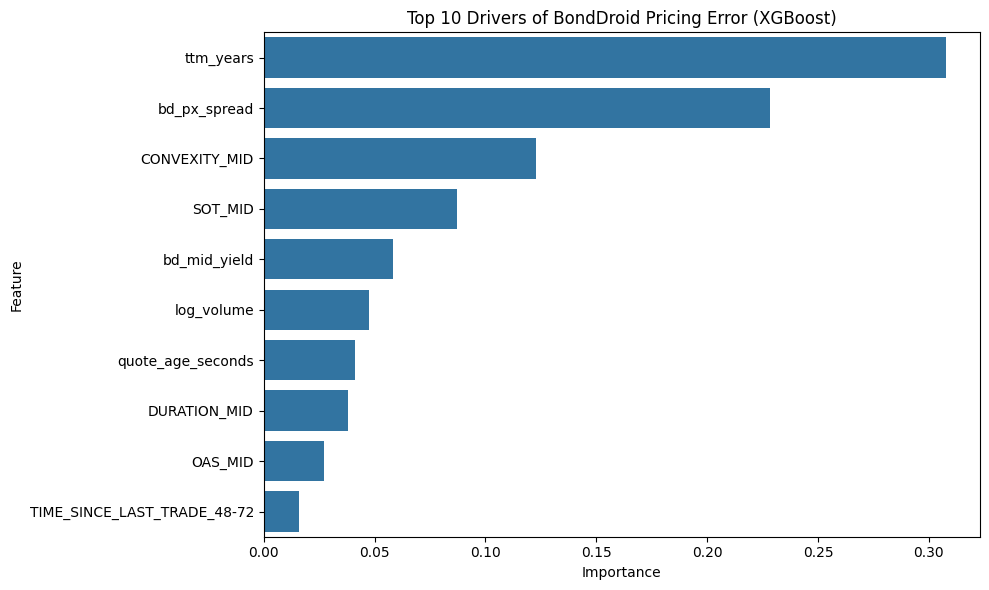

In [175]:
top = importance_xgb_com.head(10)

plt.figure(figsize=(10,6))
sns.barplot(data=top, x="Importance", y="feature")
plt.title("Top 10 Drivers of BondDroid Pricing Error (XGBoost)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

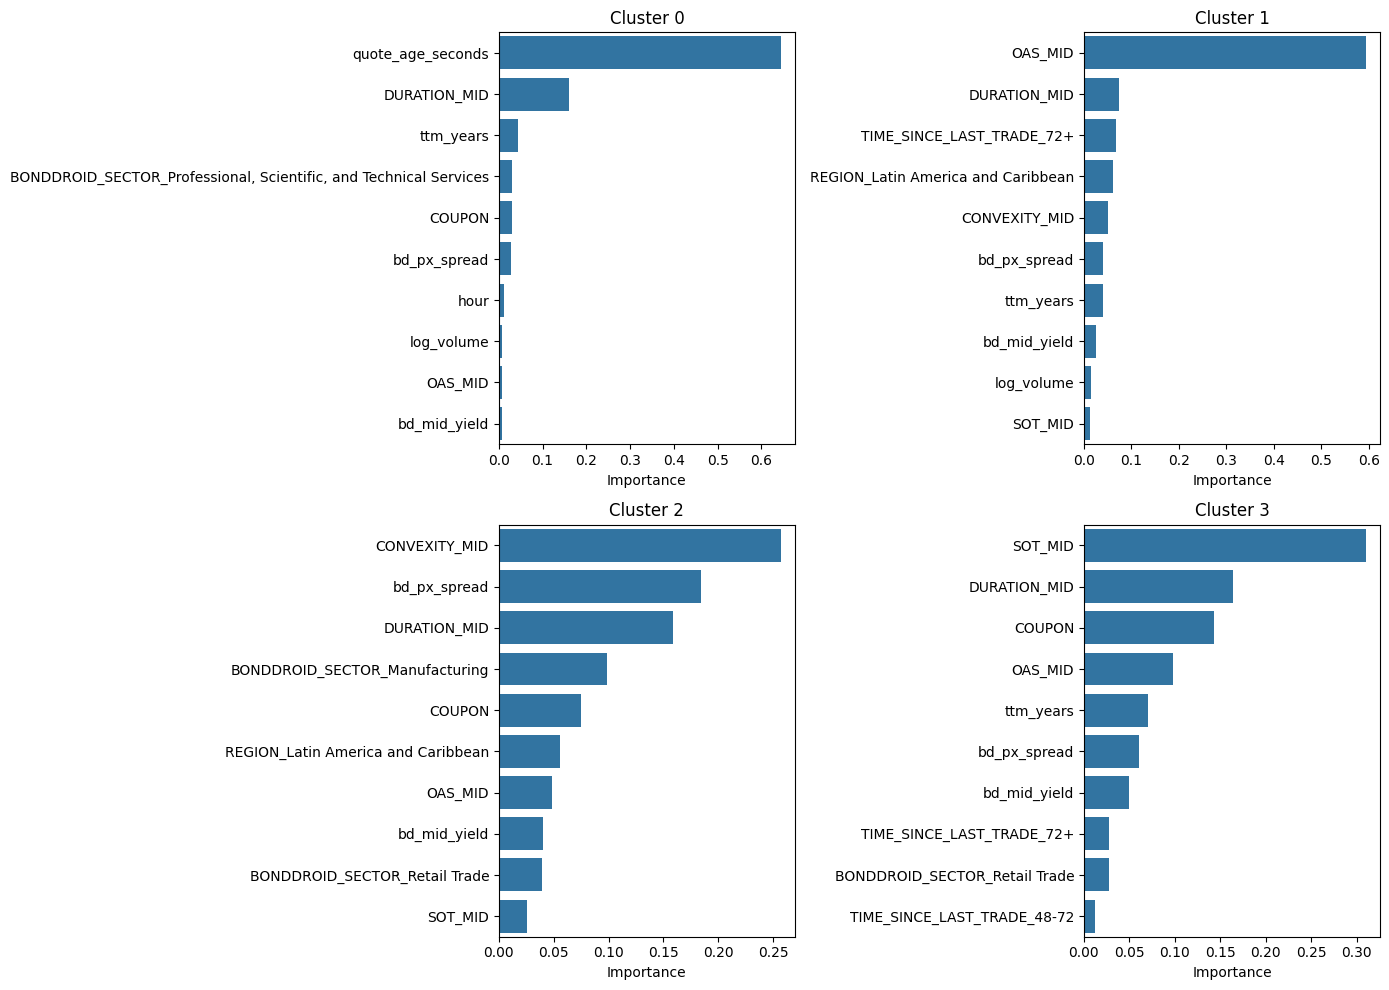

In [178]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes = axes.flatten()

for i, (c, imp) in enumerate(sorted(coef_df_xgb.items())):

    top_c = imp.head(10)

    sns.barplot(
        data=top_c,
        x="Importance",
        y="feature",
        ax=axes[i]
    )

    axes[i].set_title(f"Cluster {c}")
    axes[i].set_xlabel("Importance")
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()